In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error



In [2]:
# Load dataset
data = pd.read_csv("NIFTY50.csv")


# Convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Set Date as index
data.set_index('Date', inplace=True)

# Sort data by date (VERY IMPORTANT for time series)
data.sort_index(inplace=True)

# Keep only closing price
data = data[['Close']]
data.dropna(inplace=True)

print(data.head())


            Close
Date             
2009-03-02  43.17
2009-03-03  43.89
2009-03-04  42.52
2009-03-05  41.49
2009-03-06  38.16


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [4]:
X, y = [], []
WINDOW_SIZE = 60

for i in range(WINDOW_SIZE, len(scaled_data)):
    X.append(scaled_data[i - WINDOW_SIZE:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM: (samples, time_steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)


In [5]:
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [6]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()


/Users/krish/stock_ml/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0026
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.2467e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.4049e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.5714e-04
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.3141e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.6649e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.2362e-04
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.3188e-04
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.7598e-04
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.9462e-04
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.3537e-04
Epoch 12/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.1683e-04
Epoch 13/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.0876e-04
Epoch 14/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.0845e-04
Epoch 15/20
75/75 ━━━━━━━━━━━━━━━

In [8]:
predicted_prices = model.predict(X_test)

# Inverse scaling
predicted_prices = scaler.inverse_transform(predicted_prices)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae  = mean_absolute_error(actual_prices, predicted_prices)
print("📉 RMSE (Root Mean Squared Error):", rmse)

print("MAE :", mae)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
📉 RMSE (Root Mean Squared Error): 2.053304558113559
MAE : 1.1236323294108006


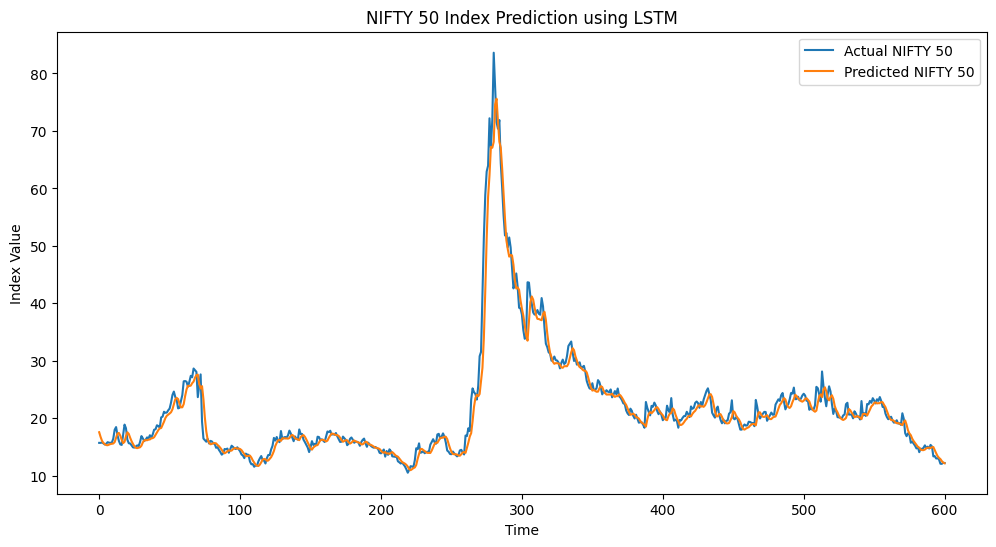

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label="Actual NIFTY 50")
plt.plot(predicted_prices, label="Predicted NIFTY 50")
plt.title("NIFTY 50 Index Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Index Value")
plt.legend()
plt.show()


In [10]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, 60, 1)

next_day_prediction = model.predict(last_60_days)
next_day_prediction = scaler.inverse_transform(next_day_prediction)

print("📈 Predicted Next Day NIFTY 50 Closing Value:",
      next_day_prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
📈 Predicted Next Day NIFTY 50 Closing Value: 12.142516
